# Return Map Analysis (Figure 6)

Reproduction and analysis of **Figure 6** of Nagatani (2006): the Poincaré
return map $H_1(m+1)$ versus $H_1(m)$ of the time headway of bus 1, for four
values of the loading parameter $\Gamma$ with fixed speedup parameters
$S_1 = 0.5$, $S_2 = 0.2$.

The return map reveals the dynamical regime at a glance:

| Panel | $\Gamma$ | Regime |
|-------|-----------|--------|
| (a)   | 0.2       | Periodic, period 11 |
| (b)   | 0.3       | Chaotic — single band |
| (c)   | 0.5       | Chaotic — two bands |
| (d)   | 0.8       | Complex chaos |

Beyond reproducing Figure 6, this notebook analyses the period-11 orbit
structure, plots the headway time series for each regime, and shows the
marginal distribution of $H_1(m)$ values.


## Mathematical Background

### Recurrence relation

The dimensionless arrival time $T_i(m)$ of bus $i$ at the origin on trip $m$
is governed by the nonlinear map (Eq. 5 of Nagatani, 2006):

$$
T_i(m+1) = T_i(m)
          + \Gamma\bigl(T_i(m)-T_{i'}(m')\bigr)
          + \frac{1}{1 + S_i\bigl(T_i(m)-T_{i'}(m')\bigr)},
$$

where $T_{i'}(m')$ is the most recent arrival of the other bus before bus $i$
on trip $m$, $\Gamma = \mu(\gamma+\eta)$ is the **loading parameter**, and
$S_i$ is the **speedup parameter** of bus $i$.

### Time headway

The **time headway** of bus 1 at trip $m$ is the gap between bus 1's arrival
and the arrival of whichever bus (1 or 2) arrived just before it in the
chronological sequence:

$$
H_1(m) = T_1(m) - T_{\mathrm{prev}}(m-1).
$$

When the two buses strictly alternate — $\ldots, B_2, B_1, B_2, B_1, \ldots$ —
this reduces to $H_1(m) = T_1(m) - T_2(m')$.

### Return map

The **return map** $H_1(m+1)$ vs $H_1(m)$ plots each consecutive headway
pair in steady state and encodes the one-step dynamics of the headway sequence.
The qualitative shape of the cloud of points identifies the dynamical regime:

* **Periodic of period $p$**: exactly $p$ isolated points arranged in a
  closed cycle $H_1^{(1)} \to H_1^{(2)} \to \cdots \to H_1^{(p)} \to H_1^{(1)}$.
* **Chaotic — one band**: a single piecewise-continuous arc.
* **Chaotic — two bands**: two disjoint arcs (a period-2 skeleton within the
  chaos).
* **Complex chaos**: a multi-valued, highly folded map.

The **identity line** $H_1(m+1)=H_1(m)$ is drawn as a reference; an
intersection marks a period-1 fixed point (perfectly constant headway).


## Setup

The notebook imports `simulate_bus_system` from the project's `simulator`
package (located at `src/simulator/`). All numerical work uses **NumPy**;
plotting uses **Matplotlib**.


In [1]:
import sys, os

SRC = os.path.abspath(os.path.join(os.getcwd(), '..'))
if SRC not in sys.path:
    sys.path.append(SRC)

import numpy as np
import matplotlib.pyplot as plt

from simulator.simulation import simulate_bus_system


## Simulation Parameters

All four panels use $S_1 = 0.5$, $S_2 = 0.2$ — the asymmetric speedup case
of Figs. 2(d) and 3(d).  The map is iterated for **2 000 trips**; only the
steady-state window $1000 \le m \le 2000$ is used to build the return map,
discarding the transient phase.

The four $\Gamma$ values sample the four qualitatively different dynamical
regimes visible in Fig. 3(d):

* $\Gamma = 0.2$: between point 1 and point 2 — **periodic, period 11**.
* $\Gamma = 0.3$: just beyond point 2 — **simple chaos**, single band.
* $\Gamma = 0.5$: between points 2 and 3 — **two-band chaos**.
* $\Gamma = 0.8$: well beyond point 3 — **complex chaos**, single broad band.


In [2]:
T1_INITIAL = 1.0
T2_INITIAL = 2.5
S1, S2     = 0.5, 0.2
NUM_TRIPS  = 2000
TRIP_MIN   = 1000
TRIP_MAX   = 2000

GAMMAS = [0.2, 0.3, 0.5, 0.8]
XLIM   = YLIM = (0.0, 1.5)

PANEL_TITLES = [
    r'(a) $\Gamma = 0.2$ — Period-11',
    r'(b) $\Gamma = 0.3$ — Chaos (1 band)',
    r'(c) $\Gamma = 0.5$ — Chaos (2 bands)',
    r'(d) $\Gamma = 0.8$ — Complex chaos',
]


## Data Extraction

The helper `extract_h1_sequence` walks the chronological arrival list produced
by `simulate_bus_system` and collects

$$
H_1(m) = T_1(m) - T_{\mathrm{prev}}(m-1)
$$

for every bus-1 trip $m$ in the steady-state window.  Pairing consecutive
values $\bigl(H_1(m),\,H_1(m+1)\bigr)$ gives the return-map coordinates.

All four simulations are run here and cached in `DATA` to avoid redundant
computation in later cells.


In [3]:
def extract_h1_sequence(arrival_time, trip_min, trip_max):
    """Return the H_1(m) sequence for bus-1 trips in [trip_min, trip_max]."""
    h1 = []
    for i in range(1, len(arrival_time)):
        r = arrival_time[i]
        if r[1] == 1 and trip_min <= r[2] <= trip_max:
            h1.append(r[0] - arrival_time[i - 1][0])
    return np.array(h1)


print('Running simulations ...')
DATA = {}
for g in GAMMAS:
    at = simulate_bus_system(T1_INITIAL, T2_INITIAL, g, S1, S2, NUM_TRIPS)
    h1 = extract_h1_sequence(at, TRIP_MIN, TRIP_MAX)
    DATA[g] = {'at': at, 'h1': h1}
    print(f'  Gamma = {g}  ->  {len(h1)} headway values')
print('Done.')


Running simulations ...
  Gamma = 0.2  ->  1001 headway values
  Gamma = 0.3  ->  1001 headway values
  Gamma = 0.5  ->  1001 headway values
  Gamma = 0.8  ->  1001 headway values
Done.


## Figure 6 — Return Maps

Each panel plots $H_1(m+1)$ against $H_1(m)$ for steady-state trips
$1000 \le m \le 2000$, with $S_1 = 0.5$, $S_2 = 0.2$.  The dashed grey line
is the identity $H_1(m+1) = H_1(m)$ (fixed-point reference).

* **(a) $\Gamma = 0.2$**: 11 isolated points — period-11 orbit.
* **(b) $\Gamma = 0.3$**: a single piecewise arc — simple chaotic attractor.
* **(c) $\Gamma = 0.5$**: two disconnected arcs — two-band chaos.
* **(d) $\Gamma = 0.8$**: a complex, multi-valued map — fully developed chaos.


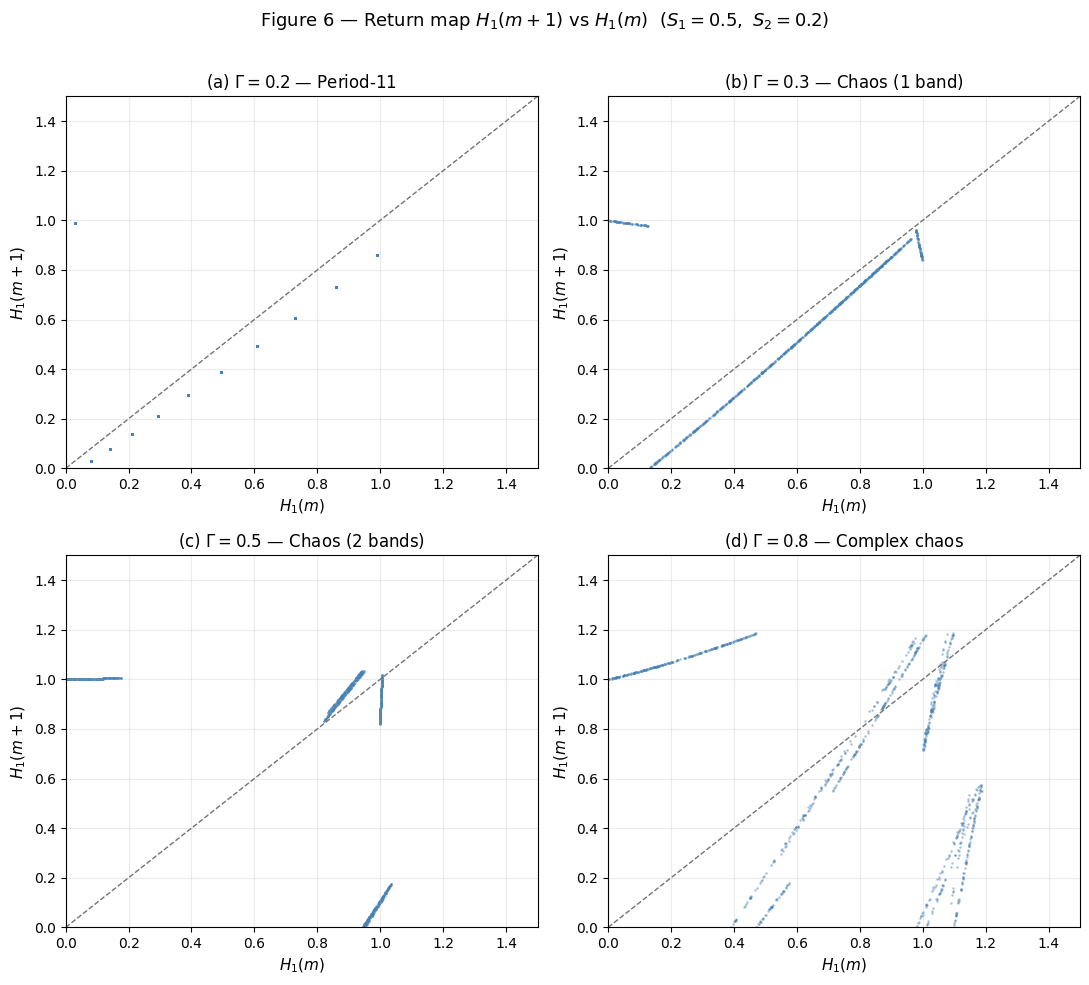

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, gamma, title in zip(axes.flat, GAMMAS, PANEL_TITLES):
    h1 = DATA[gamma]['h1']
    ax.scatter(h1[:-1], h1[1:], s=3, alpha=0.5, color='steelblue', linewidths=0)
    ax.plot(XLIM, XLIM, color='0.45', lw=1.0, ls='--')
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.set_xlabel(r'$H_1(m)$',   fontsize=11)
    ax.set_ylabel(r'$H_1(m+1)$', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.25)

fig.suptitle(
    r'Figure 6 — Return map $H_1(m+1)$ vs $H_1(m)$  ($S_1=0.5,\ S_2=0.2$)',
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Period-11 Orbit Analysis ($\Gamma = 0.2$)

At $\Gamma = 0.2$ the system is in a periodic orbit.  We identify the period
by counting the distinct $H_1$ values visited in steady state.  Two
visualisations are provided:

1. **Return map with labelled points** — each of the 11 orbit points is
   annotated with its visitation order.
2. **Headway time series** $H_1(m)$ vs $m$ for 44 steady-state trips — the
   period-11 pattern repeats every 11 trips.


Period detected: 11
H_1 orbit values (sorted):
   1.  0.030928
   2.  0.079846
   3.  0.139614
   4.  0.210945
   5.  0.294034
   6.  0.388511
   7.  0.493511
   8.  0.607804
   9.  0.729979
  10.  0.858619
  11.  0.990957


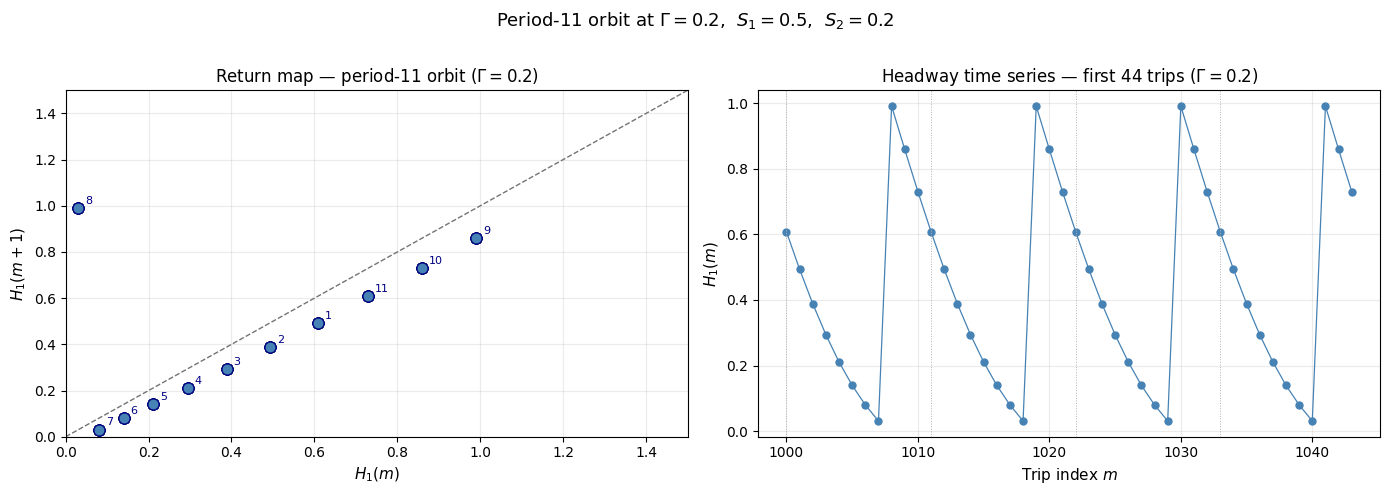

In [5]:
h1_p = DATA[0.2]['h1']

# --- Identify distinct orbit points (tolerance-based) ---
tol = 1e-4
unique_pts = []
for v in h1_p:
    if not any(abs(v - u) < tol for u in unique_pts):
        unique_pts.append(float(v))

period = len(unique_pts)
print(f'Period detected: {period}')
print('H_1 orbit values (sorted):')
for k, v in enumerate(sorted(unique_pts), 1):
    print(f'  {k:2d}.  {v:.6f}')

# --- Trace visitation order for the first complete cycle ---
orbit_order = []
seen_keys = set()
for v in h1_p:
    key = round(float(v), 4)
    if key not in seen_keys:
        seen_keys.add(key)
        orbit_order.append(float(v))
    if len(orbit_order) == period:
        break

# --- Build return-map coordinates for the orbit ---
orb_x = orbit_order
orb_y = orbit_order[1:] + [orbit_order[0]]   # cyclic shift

# --- Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: return map with orbit labels
ax1.scatter(h1_p[:-1], h1_p[1:], s=60, color='steelblue',
            edgecolors='navy', linewidths=0.6, zorder=3)
for k, (xp, yp) in enumerate(zip(orb_x, orb_y), 1):
    ax1.annotate(str(k), (xp, yp),
                 textcoords='offset points', xytext=(5, 3),
                 fontsize=8, color='navy')
ax1.plot(XLIM, XLIM, color='0.45', lw=1.0, ls='--')
ax1.set_xlim(*XLIM)
ax1.set_ylim(*YLIM)
ax1.set_xlabel(r'$H_1(m)$',   fontsize=11)
ax1.set_ylabel(r'$H_1(m+1)$', fontsize=11)
ax1.set_title(r'Return map — period-11 orbit ($\Gamma = 0.2$)', fontsize=12)
ax1.grid(alpha=0.25)

# Right panel: time series
m_vals = np.arange(len(h1_p)) + TRIP_MIN
n_show = 44
ax2.plot(m_vals[:n_show], h1_p[:n_show], 'o-', color='steelblue', ms=5, lw=0.9)
for k in range(0, n_show, period):
    ax2.axvline(m_vals[k], color='0.7', lw=0.7, ls=':')
ax2.set_xlabel('Trip index $m$', fontsize=11)
ax2.set_ylabel(r'$H_1(m)$',     fontsize=11)
ax2.set_title(r'Headway time series — first 44 trips ($\Gamma = 0.2$)', fontsize=12)
ax2.grid(alpha=0.25)

fig.suptitle(
    r'Period-11 orbit at $\Gamma = 0.2$,  $S_1 = 0.5$,  $S_2 = 0.2$',
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Headway Time Series Across All Regimes

Plotting $H_1(m)$ vs $m$ for all four $\Gamma$ values in a single figure
illustrates the qualitative change from ordered to disordered dynamics:

* **Periodic ($\Gamma = 0.2$)**: the sequence oscillates in a fixed, repeating
  pattern — visually a regular staircase.
* **Simple chaos ($\Gamma = 0.3$)**: the sequence is irregular but confined to a
  narrow band.
* **Two-band chaos ($\Gamma = 0.5$)**: the sequence jumps between two levels,
  reflecting the two-band attractor structure.
* **Complex chaos ($\Gamma = 0.8$)**: the sequence fluctuates over a much wider
  range with no visible pattern.


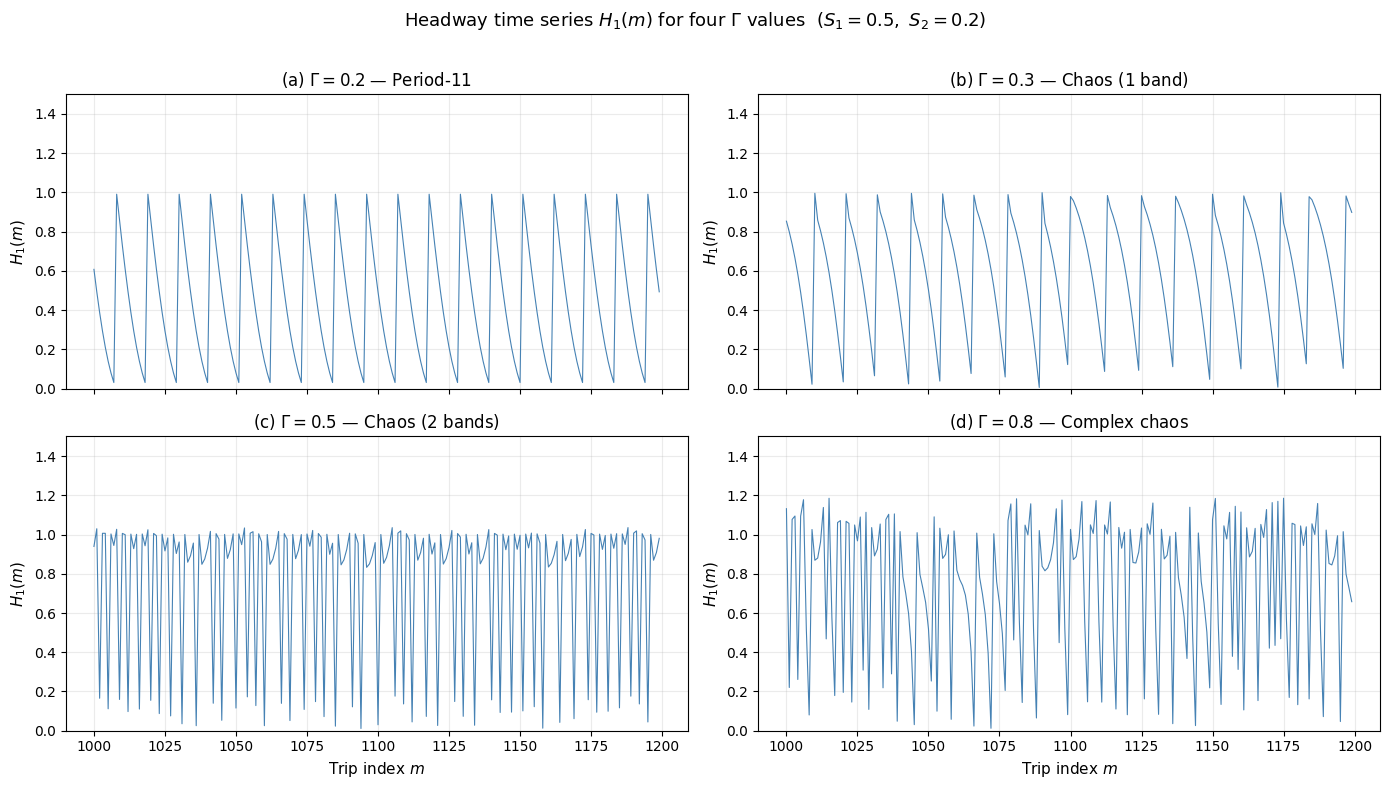

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

n_show = 200   # number of steady-state trips to display

for ax, gamma, title in zip(axes.flat, GAMMAS, PANEL_TITLES):
    h1 = DATA[gamma]['h1']
    m_vals = np.arange(min(n_show, len(h1))) + TRIP_MIN
    ax.plot(m_vals, h1[:n_show], lw=0.8, color='steelblue')
    ax.set_ylabel(r'$H_1(m)$', fontsize=11)
    ax.set_ylim(0, 1.5)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.25)

for ax in axes[1]:
    ax.set_xlabel('Trip index $m$', fontsize=11)

fig.suptitle(
    r'Headway time series $H_1(m)$ for four $\Gamma$ values  ($S_1=0.5,\ S_2=0.2$)',
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Attractor Structure: Marginal Distributions of $H_1(m)$

The **marginal distribution** of $H_1(m)$ (histogram of headway values in
steady state) complements the return map by showing *where* the dynamics
spends its time.

* **Period-$p$ orbit**: $p$ equal-weight delta spikes at the $p$ orbit values.
* **Chaotic — 1 band**: a single broad, continuous distribution.
* **Chaotic — 2 bands**: two separated humps, matching the two arcs in the
  return map.
* **Complex chaos**: a broad, nearly flat distribution.

Comparing the four panels shows the progressive transition from a discrete
spectrum (periodic) to a continuous one (chaotic) as $\Gamma$ increases.


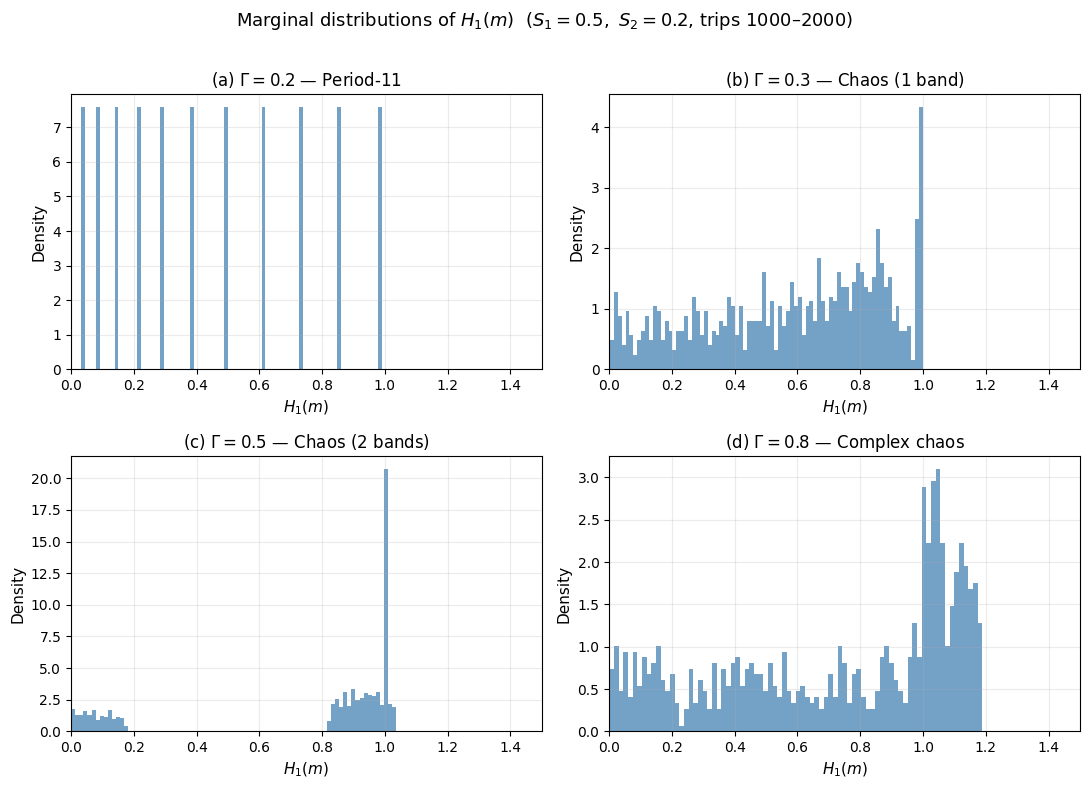

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, gamma, title in zip(axes.flat, GAMMAS, PANEL_TITLES):
    h1 = DATA[gamma]['h1']
    ax.hist(h1, bins=80, color='steelblue', edgecolor='none',
            density=True, alpha=0.75)
    ax.set_xlabel(r'$H_1(m)$', fontsize=11)
    ax.set_ylabel('Density',   fontsize=11)
    ax.set_xlim(0, 1.5)
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.25)

fig.suptitle(
    r'Marginal distributions of $H_1(m)$  ($S_1=0.5,\ S_2=0.2$, trips 1000–2000)',
    fontsize=13,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Discussion

### Period-11 orbit ($\Gamma = 0.2$)

The return map at $\Gamma = 0.2$ consists of exactly **11 isolated points**,
confirming the period-11 orbit described in the paper.  The headway time
series cycles through these 11 values in a fixed order every 11 trips, and
the marginal distribution shows 11 sharp spikes.

This is part of a **period-adding cascade**: as $\Gamma$ increases from 0
the period grows through a sequence of additions (3 → 5 → 7 → 9 → 11 → …)
until chaos sets in at point 2 ($\Gamma \approx 0.248$) in Fig. 3(d).

### Single-band chaos ($\Gamma = 0.3$)

At $\Gamma = 0.3$ the return map is a single piecewise-linear arc with a
pronounced fold — the hallmark of a **simple chaotic attractor**.  The fold
originates from the abrupt change in headway when bus 1 is overtaken by bus 2,
causing $H_1$ to jump discontinuously.  The marginal distribution is a single
broad hump.

### Two-band chaos ($\Gamma = 0.5$)

At $\Gamma = 0.5$ the return map splits into **two disconnected arcs**,
corresponding to the two extended bands in the bifurcation diagram
(Fig. 2(d)).  The dynamics alternates between two sub-intervals of headway
on successive trips — a period-2 skeleton embedded within the chaos.  The
marginal distribution shows two clearly separated humps.

### Complex chaos ($\Gamma = 0.8$)

At $\Gamma = 0.8$ the return map is a highly folded, multi-valued curve —
**fully developed chaos**.  The two bands have merged back into one (as seen
in Fig. 2(d) for $\Gamma \gtrsim 0.6$), and the marginal distribution is
broad and nearly uniform over a wide headway range.

### Implications for bus scheduling

The operational interpretation is direct:

* **Regular** ($\Gamma < 0.167$): headway is constant — perfect scheduling.
* **Periodic** ($0.167 < \Gamma < 0.248$): headway fluctuates in a fixed
  cycle — irregular but *predictable* in principle.
* **Chaotic** ($\Gamma > 0.248$): headway is unpredictable from trip to
  trip — reliable scheduling requires active control (speedup).

Increasing $S$ shifts the onset of chaos to higher $\Gamma$, as shown in
the phase diagram (Fig. 8), allowing regular or periodic operation under
heavier passenger loads.
